In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import tqdm
import glob
import re
import pickle
import os
from typing import List
import seaborn as sns
#sns.set() #推奨されないみたい
sns.set_style("white"+"grid")
sns.set_palette("Paired")
import time

plt.rcParams['font.family'] = 'Times New Roman' # Fonts
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 24 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更されます
color_arr=plt.rcParams['axes.prop_cycle'].by_key()['color']

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
def isFloat(s:str)->bool:
    try:
        float(s)
        return True
    except:
        return False
    
def fix_parameter_line_to_dict(parameter_string:str):
    response={}
    key=""
    for x in parameter_string.split("_"):
        if not isFloat(x):
            if not '~' in x:
                if key!="":
                    key+="_"
                key+=x
            else:
                list_param=x.split('~')
                if len(list_param)>2:
                    response[list_param[0]]=','.join(list_param[1:-1])
        else:
            response[key]=float(x)
            key=""
    return response

In [3]:
grid_sizes=[x.split('/')[-1] for x in glob.glob("road_data/*")]
grid_sizes
filenames=glob.glob(f"road_data/{grid_sizes[2]}/*")
filenames.sort()
filenames

['road_data/Nxy_8_8/seed_1.csv',
 'road_data/Nxy_8_8/seed_10.csv',
 'road_data/Nxy_8_8/seed_100.csv',
 'road_data/Nxy_8_8/seed_11.csv',
 'road_data/Nxy_8_8/seed_12.csv',
 'road_data/Nxy_8_8/seed_13.csv',
 'road_data/Nxy_8_8/seed_14.csv',
 'road_data/Nxy_8_8/seed_15.csv',
 'road_data/Nxy_8_8/seed_16.csv',
 'road_data/Nxy_8_8/seed_17.csv',
 'road_data/Nxy_8_8/seed_18.csv',
 'road_data/Nxy_8_8/seed_19.csv',
 'road_data/Nxy_8_8/seed_2.csv',
 'road_data/Nxy_8_8/seed_20.csv',
 'road_data/Nxy_8_8/seed_21.csv',
 'road_data/Nxy_8_8/seed_22.csv',
 'road_data/Nxy_8_8/seed_23.csv',
 'road_data/Nxy_8_8/seed_24.csv',
 'road_data/Nxy_8_8/seed_25.csv',
 'road_data/Nxy_8_8/seed_26.csv',
 'road_data/Nxy_8_8/seed_27.csv',
 'road_data/Nxy_8_8/seed_28.csv',
 'road_data/Nxy_8_8/seed_29.csv',
 'road_data/Nxy_8_8/seed_3.csv',
 'road_data/Nxy_8_8/seed_30.csv',
 'road_data/Nxy_8_8/seed_31.csv',
 'road_data/Nxy_8_8/seed_32.csv',
 'road_data/Nxy_8_8/seed_33.csv',
 'road_data/Nxy_8_8/seed_34.csv',
 'road_data/Nxy_

In [4]:
df=pd.read_csv(filenames[80])

In [5]:
df["counter_ratio"]=(df["counter"]-df["counter"].min())/(df["counter"].max()-df["counter"].min())
(df["counter"]/150000).mean()

np.float64(0.009689000000000001)

0.009689000000000001


(-200.0, 4200.0)

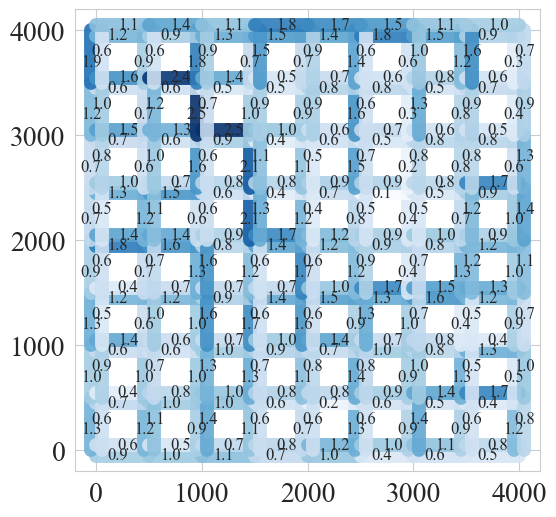

In [6]:
simulation_time=50000+100000
print((df["counter"]/simulation_time).mean())
fig=plt.figure(figsize=(6,6))
axe=fig.add_subplot(111)
cm = plt.get_cmap("Blues")
#cm = plt.get_cmap("Reds")
for i in range(len(df)):
    e=df.iloc[i]
    if e["from_point_x"]<0 or 4000<e["from_point_x"] or e["from_point_y"]<0 or 4000<e["from_point_y"]:
        continue
    if e["to_point_x"]<0 or 4000<e["to_point_x"] or e["to_point_y"]<0 or 4000<e["to_point_y"]:
        continue
    dx=(e["from_point_x"]-e["to_point_x"])*0.1
    dy=(e["from_point_y"]-e["to_point_y"])*0.1
    axe.plot([e["from_point_x"]+dy,e["to_point_x"]+dy],[e["from_point_y"]+dx,e["to_point_y"]+dx],linewidth=10,alpha=0.9,color=cm(e["counter_ratio"]))
    axe.text((e["from_point_x"]+e["to_point_x"])/2+dx+dy,(e["from_point_y"]+e["to_point_y"])/2+dx+dy,f"{e["counter"]/simulation_time/0.01:.1f}",fontsize=12,horizontalalignment='center',verticalalignment='center')

axe.set_ylim(-200.0,4200.0)
axe.set_xlim(-200.0,4200.0)
#plt.colorbar(cm)

In [12]:
gs=grid_sizes[2]
filenames=glob.glob(f"road_data/{gs}/*")

LAMBDA=0.01
for fname in filenames:
    df=pd.read_csv(fname)
    ct=[]
    for i in range(len(df)):
        e=df.iloc[i]
        is_center=False
        if 1800<e["from_point_x"]<2200 and 1800<e["from_point_y"]<2200:
            is_center=True
        if 1800<e["to_point_x"]<2200 and 1800<e["to_point_y"]<2200:
            is_center=True
        if is_center:
            ct.append(e["counter"]/simulation_time/LAMBDA)
    
    if(np.mean(ct)<0.6):
        simulation_time=50000+100000
        print(fname,(df["counter"]/simulation_time).mean(),ct)
        df["counter_ratio"]=(df["counter"]-df["counter"].min())/(df["counter"].max()-df["counter"].min())
        fig=plt.figure(figsize=(6,6))
        axe=fig.add_subplot(111)
        cm = plt.get_cmap("Blues")
        #cm = plt.get_cmap("Reds")
        for i in range(len(df)):
            e=df.iloc[i]
            if e["from_point_x"]<0 or 4000<e["from_point_x"] or e["from_point_y"]<0 or 4000<e["from_point_y"]:
                continue
            if e["to_point_x"]<0 or 4000<e["to_point_x"] or e["to_point_y"]<0 or 4000<e["to_point_y"]:
                continue
            dx=(e["from_point_x"]-e["to_point_x"])*0.1
            dy=(e["from_point_y"]-e["to_point_y"])*0.1
            axe.plot([e["from_point_x"]+dy,e["to_point_x"]+dy],[e["from_point_y"]+dx,e["to_point_y"]+dx],linewidth=10,alpha=0.9,color=cm(e["counter_ratio"]))
            axe.text((e["from_point_x"]+e["to_point_x"])/2+dx+dy,(e["from_point_y"]+e["to_point_y"])/2+dx+dy,f"{e["counter"]/simulation_time/0.01:.1f}",fontsize=12,horizontalalignment='center',verticalalignment='center')
        axe.set_ylim(-200.0,4200.0)
        axe.set_xlim(-200.0,4200.0)
        #plt.colorbar(cm)
        dir=f"fig/road_prob/{gs}"
        os.makedirs(f"{dir}/",exist_ok=True)
        fig.savefig(f"{dir}/{fname.split("/")[-1][:-4]}.png", bbox_inches="tight", pad_inches=0.05)
        plt.close()
        print(f"{dir}/{fname.split("/")[-1][:-4]}.png")
        


road_data/Nxy_8_8/seed_80.csv 0.009900814814814815 [np.float64(0.378), np.float64(0.42133333333333334), np.float64(0.3486666666666666), np.float64(1.2826666666666666), np.float64(0.372), np.float64(0.3766666666666667), np.float64(1.208), np.float64(0.38133333333333336)]
fig/road_prob/Nxy_8_8/seed_80.png
road_data/Nxy_8_8/seed_24.csv 0.009635518518518517 [np.float64(0.37733333333333335), np.float64(0.47733333333333333), np.float64(0.292), np.float64(0.7653333333333333), np.float64(0.4293333333333333), np.float64(0.582), np.float64(0.7966666666666666), np.float64(0.426)]
fig/road_prob/Nxy_8_8/seed_24.png
road_data/Nxy_8_8/seed_43.csv 0.00970487037037037 [np.float64(0.564), np.float64(0.4126666666666666), np.float64(0.44066666666666665), np.float64(0.3873333333333333), np.float64(0.15933333333333333), np.float64(0.8586666666666666), np.float64(0.5826666666666667), np.float64(0.29666666666666663)]
fig/road_prob/Nxy_8_8/seed_43.png
